# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [39]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [40]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


In [41]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
print("Tỷ lệ missing của tất cả các cột:")
print(df.isnull().mean() * 100)

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ["alive", "who", "adult_male", "class", "deck", "embark_town"]
for l in leaky:
    if l in df.columns:
        df = df.drop(columns=l)

print("Các cột còn lại:", list(df.columns))


Tỷ lệ missing của tất cả các cột:
survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Cột `alive` chính là biến mục tiêu `survived` nhưng được ghi dưới dạng chữ ('yes'/'no'). Nếu giữ lại cột này trong tập đặc trưng đầu vào, mô hình học máy sẽ dễ dàng đạt độ chính xác ~100% bằng cách sao chép/tra cứu trực tiếp giá trị của `alive` để dự đoán `survived` mà không thực sự học được bất kỳ mối liên hệ bản chất nào từ các đặc trưng khác (như tuổi, giới tính, hạng vé). Điều này gây ra hiện tượng **data leakage** (rò rỉ nhãn) nghiêm trọng, khiến mô hình đạt điểm số tối đa trong quá trình phát triển nhưng hoàn toàn vô dụng trên thực tế khi gặp dữ liệu mới không có sẵn cột `alive`.


---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [42]:
# TODO 2: shape, info, describe
print(f"Shape: {df.shape}")
print("target: survived\n")
print(df.info())
print(df.describe())
print(df.describe(include=['object', 'category']))


Shape: (891, 9)
target: survived

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
 8   alone     891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 56.7+ KB
None
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000   



- Biến số: age, sibsp, parch, fare
- Biến phân loại: sex (male / female), embarked (nhiều lớp) -> ko phải kiểu dữ liệu thường


---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [43]:
# TODO 3: bảng missing (count + %)
missing_count = df.isnull().sum()
missing_pct = df.isnull().mean() * 100
missing_df = pd.DataFrame({
    'Số lượng thiếu': missing_count,
    'Tỷ lệ thiếu': missing_pct
})

missing_df = missing_df[missing_df['Số lượng thiếu'] > 0]
print(missing_df)


          Số lượng thiếu  Tỷ lệ thiếu
age                  177    19.865320
embarked               2     0.224467


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| `age` | ~19.87% | `median` | phân phối tuổi tác thường có độ lệch nhẹ và có thể xuất hiện các outlier điền không làm dịch chuyển phân phối quá nhiều. Gỉa sử ta điền bằng mean thì khi đó giả sử có quá nhiều người già thì có thể gán nhầm. Điền bằng mode thì càng không do thiếu đến 20% ta không thể kết luận chính xác mode là gì|
| `embarked` | ~0.22% |  `mode`  | thiếu ít nên ta điền bằng mode |


---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [44]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
from scipy import stats

def dem_outlier_iqr(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return ((s < lower_bound) | (s > upper_bound)).sum()

def dem_outlier_zscore(s, threshold=3.0):
    s_clean = s.dropna()
    z_scores = np.abs(stats.zscore(s_clean))
    return (z_scores > threshold).sum()

for col in ["age", "fare"]:
    print(f"Cột {col}:")
    print(f"  - Số outlier theo IQR: {dem_outlier_iqr(df[col])}")
    print(f"  - Số outlier theo Z-score: {dem_outlier_zscore(df[col])}")


Cột age:
  - Số outlier theo IQR: 11
  - Số outlier theo Z-score: 2
Cột fare:
  - Số outlier theo IQR: 116
  - Số outlier theo Z-score: 20




ta nên giữ các outlier của cột fare vì đơn giản trên tàu titanic có hàng thương gia, vì vậy giá thành của hàng này sẽ càng hơn bình thường rất nhiều, đây là một đặc điểm quan trọng giúp ta phân biệt giữa khác hàng, vị trí phòng, ưu tiên hành khách vì vậy mà ta bắt buộc phải giữ


---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

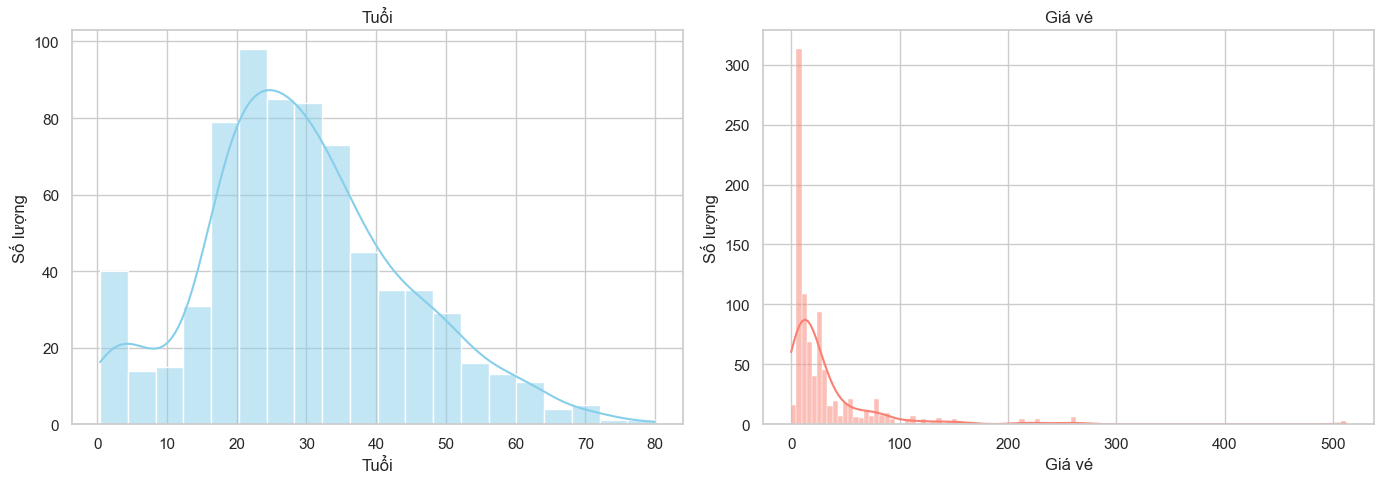

In [45]:
# TODO 5a: Histogram age & fare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x="age", kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Tuổi")
axes[0].set_xlabel("Tuổi")
axes[0].set_ylabel("Số lượng")

sns.histplot(data=df, x="fare", kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Giá vé")
axes[1].set_xlabel("Giá vé")
axes[1].set_ylabel("Số lượng")

plt.tight_layout()
plt.show()


C:\Users\Wingery\AppData\Local\Temp\ipykernel_17048\4224301853.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="survived", y="fare", palette="Set2")


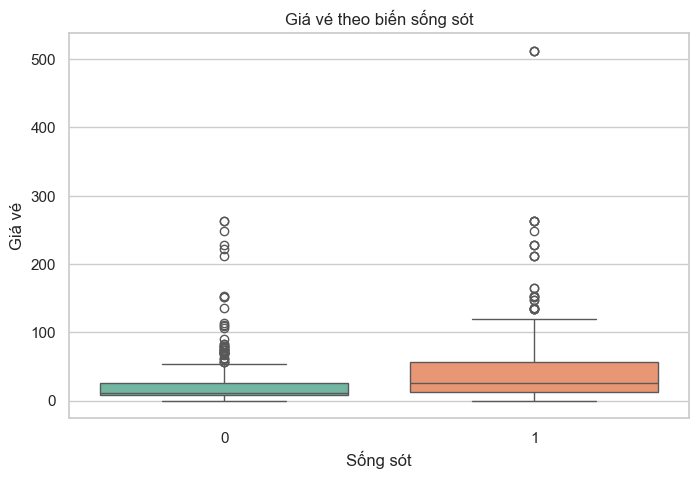

In [46]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="survived", y="fare", palette="Set2")
plt.title("Giá vé theo biến sống sót")
plt.xlabel("Sống sót")
plt.ylabel("Giá vé")
plt.show()


C:\Users\Wingery\AppData\Local\Temp\ipykernel_17048\4179473846.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="sex", y="survived", ax=axes[0], errorbar=None, palette="pastel")
C:\Users\Wingery\AppData\Local\Temp\ipykernel_17048\4179473846.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="pclass", y="survived", ax=axes[1], errorbar=None, palette="pastel")


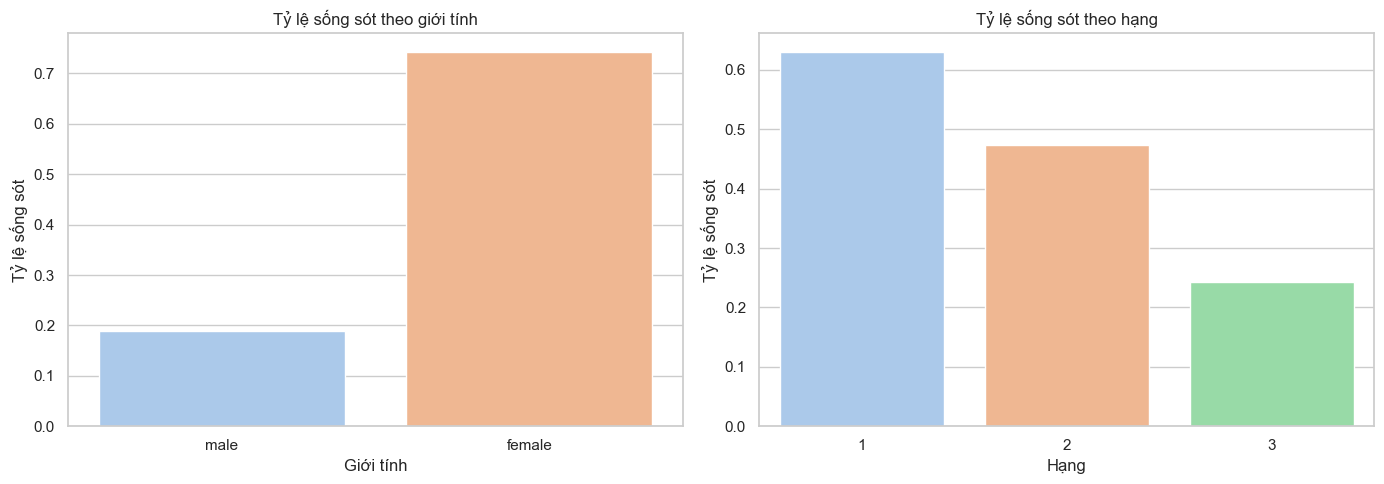

In [47]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df, x="sex", y="survived", ax=axes[0], errorbar=None, palette="pastel")
axes[0].set_title("Tỷ lệ sống sót theo giới tính")
axes[0].set_xlabel("Giới tính")
axes[0].set_ylabel("Tỷ lệ sống sót")

sns.barplot(data=df, x="pclass", y="survived", ax=axes[1], errorbar=None, palette="pastel")
axes[1].set_title("Tỷ lệ sống sót theo hạng")
axes[1].set_xlabel("Hạng")
axes[1].set_ylabel("Tỷ lệ sống sót")

plt.tight_layout()
plt.show()


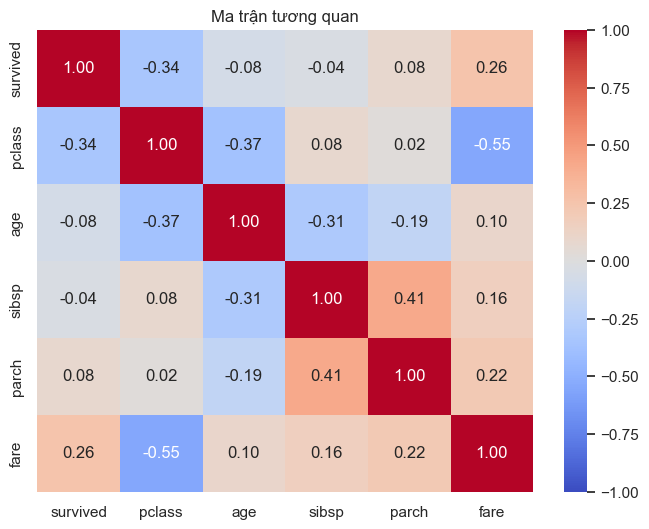

In [48]:
# TODO 5d: Heatmap correlation
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Ma trận tương quan")
plt.show()


**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- **Histogram:** Phân phối của tuổi thể hiện đa số hành khách còn khá trẻ chỉ trong khoảng 20-40 tuổi. Trong khi đó, phân phối của giá vé thì lệch hẳn sang trái cho thấy đại đa số hành khác trên tàu titanic mua vé vs giá thấp (<50) với thiểu số các đại gia mua hạng thương gia

- **Boxplot:** hành khách sống sót có phân phối giá vé và giá vé trung vị cao hơn đáng kể so với nhóm không sống sót. Điều này cho thấy vé càng đắt thì tỉ lệ sống sót càng cao.

- **Bar survival:** Nữ giới có tỷ lệ sống sót cao nhất vs 74% so với nam giới 19%. Hành khách hạng sang có tỷ lệ sống sót lớn nhất (60%) và giảm dần xuống hạng 2 (47%) và thấp nhất là hạng 3 (24%)

- **Heatmap:** fare và pclass (-0.55) nghĩa là hạng vé càng nhỏ thì giá vé càng cao, survived và fare (0.26) và pclass (-0.34) cho thấy nếu mua giá vé cao thì càng dễ sống sót 


---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [49]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns="survived")
y = df["survived"]

X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.17647, stratify=y_tmp, random_state=42)

print(f"Train shape: {X_train.shape}, Tỷ lệ sống sót: {y_train.mean():.3f}")
print(f"Val shape:   {X_val.shape}, Tỷ lệ sống sót: {y_val.mean():.3f}")
print(f"Test shape:  {X_test.shape}, Tỷ lệ sống sót: {y_test.mean():.3f}")


Train shape: (623, 8), Tỷ lệ sống sót: 0.384
Val shape:   (134, 8), Tỷ lệ sống sót: 0.388
Test shape:  (134, 8), Tỷ lệ sống sót: 0.381


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [50]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)            
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

print("Train shape:", X_train_t.shape)
print("Đặc trưng sau biến đổi:", list(preprocess.get_feature_names_out()))


Train shape: (623, 10)
Đặc trưng sau biến đổi: ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']



fit trên tập train đảm bảo rằng mô hình chỉ học các tham từ train mà không nhìn trước tương lai. Tập val và test đóng vai trò là dữ liệu mới (dữ liệu tương lai) và chỉ được transform bằng các tham số từ train, nếu fit trên toàn bộ dữ liệu trước khi chia hoặc fit cả val/test thì thông tin tương lai sẽ bị rò rỉ vào tập train, mô hình đã biết trước được đáp án rồi thì cần gì phải học làm gì nx. Vì vậy ta chỉ fit trên tập train để buộc mô hình phải học và phải đánh giá trên val/test


---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [51]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
print(df["survived"].value_counts())
print(df["survived"].value_counts(normalize=True))


survived
0    549
1    342
Name: count, dtype: int64
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


**Trả lời 8:**

- survived có 0 chiếm 61.62% và 1 chiếm 38.38% nên ta thấy nó hơi nghiệng về survived
- giả sử có 90% lớp 0 và 10% lớp 1, khi đó một mô hình dự đoán toàn bộ hành khách ngủm vẫn đạt 90% accuracy vì acccuracy chỉ đo tỉ lệ phần trăm câu trả lời đúng. Khi đó accuracy cao nhưng mô hình không có ý nghĩa gì hết
- F1-score là trung bình điều hòa của precision và recall, giúp đánh giá cân bằng FP (precision) và TP (recall). Ngoài ra F1 còn phù hợp trong bối cảnh các lớp có sự chênh lệch phân phối. Nhưng theo kinh nghiệm của tôi thì cứ đánh hết accuracy f1 precision và recall đi cho dễ nhìn


---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Đặc trưng có tương quan mạnh nhất tới khả năng sống sót là giới tính với tỷ lệ sống sót của nữ giới vượt trội  sau đó là hạng vé (1 > 2 > 3)

2. Cột thiếu nhiều nhất là deck (77%) nên bị loại bỏ hoàn toàn. Cột thiếu tiếp theo là age và điền median vô

3. tỷ lệ biến mục tiên cho thấy sự mất cân bằng nhẹ giữa sống sót và không sóng sót, do đó việc lựa chọn các chỉ số đánh giá đa chiều như F1-score hay precision/recall nên được ưu tiên

4. các đặc trưng số (`age`, `sibsp`, `parch`, `fare`) được chuẩn hóa bằng RobustScaler để xử lý outlier của fare, trong khi các biến phân loại (`sex`, `embarked`) được mã hóa qua `OneHotEncoder` chuyển sang vector nhị phân

5. phụ nữ và trẻ em được ưu tiên hơn hẳn đàn ông nhưng điều bất ngờ là người có vé hạng sang lại được cứu trước trong khi trong hoàn cảnh đó thì ai hạng nào cũng như nhau cả thôi


---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

family_size với survived: 0.01663898928274523


C:\Users\Wingery\AppData\Local\Temp\ipykernel_17048\1940020996.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_bonus, x="family_size", y="survived", palette="Blues")


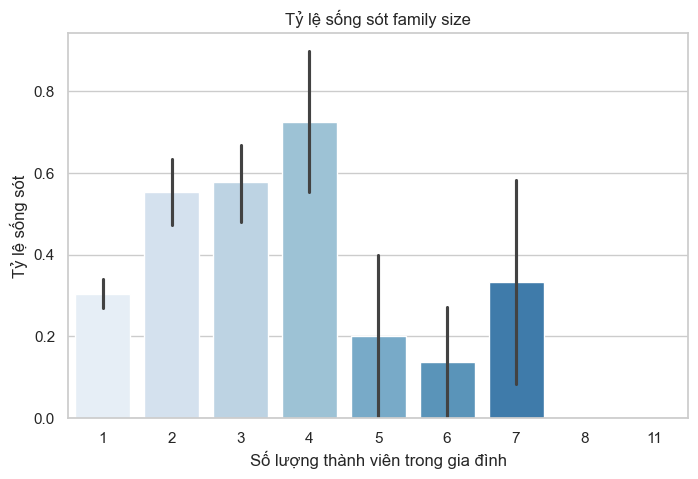

In [52]:
# (tùy chọn) code cho phần Bonus
# Thử thách 1: Feature engineering - tạo đặc trưng family_size
df_bonus = df.copy()
df_bonus['family_size'] = df_bonus['sibsp'] + df_bonus['parch'] + 1
print("family_size với survived:", df_bonus[['family_size', 'survived']].corr().iloc[0, 1])

plt.figure(figsize=(8, 5))
sns.barplot(data=df_bonus, x="family_size", y="survived", palette="Blues")
plt.title("Tỷ lệ sống sót family size")
plt.xlabel("Số lượng thành viên trong gia đình")
plt.ylabel("Tỷ lệ sống sót")
plt.show()


với khoảng từ 1-4 người tỉ lệ sống sót của bạn là cao nhất

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
